In [1]:
#!pip install librosa soundfile tqdm -q

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings('ignore')

In [3]:
try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

In [4]:
class Config:
    # Google Drive paths
    GDRIVE_ROOT = '/content/drive/MyDrive/MELD'

    # Audio processing parameters
    SAMPLE_RATE = 16000  # Standard for speech
    DURATION = 5  # Maximum duration in seconds
    N_MFCC = 40  # Number of MFCC features
    N_MELS = 128  # Number of mel bands
    HOP_LENGTH = 512
    N_FFT = 2048

    EXTRACT_MFCC = True
    EXTRACT_MEL_SPEC = True
    EXTRACT_CHROMA = True
    EXTRACT_SPECTRAL_CONTRAST = True

    # Output paths
    OUTPUT_DIR = '/content/preprocessed_data'

    # Emotion labels for MELD dataset
    EMOTION_LABELS = {
        'anger': 0,
        'disgust': 1,
        'fear': 2,
        'joy': 3,
        'neutral': 4,
        'sadness': 5,
        'surprise': 6
    }

config = Config()


In [10]:
def explore_dataset_structure(base_path):
    """Explore and print the dataset structure"""
    print("\n" + "="*60)
    print("DATASET STRUCTURE EXPLORATION")
    print("="*60)

    for split in ['train', 'dev', 'test']:
        split_path = os.path.join(base_path, split)
        if os.path.exists(split_path):
            files = os.listdir(split_path)
            print(f"\n{split.upper()} folder:")
            print(f"  Total files: {len(files)}")
            print(f"  Sample files: {files[:5]}")
        else:
            print(f"\n{split.upper()} folder: NOT FOUND")

    print("\n" + "="*60)

In [11]:
def extract_audio_features(audio_path, sr=16000):
    """
    Extract comprehensive audio features for emotion recognition

    Args:
        audio_path: Path to audio file
        sr: Sample rate

    Returns:
        Dictionary of extracted features
    """
    try:
        # Load audio file
        y, sr = librosa.load(audio_path, sr=sr, duration=config.DURATION)

        # Pad or trim to fixed length
        target_length = sr * config.DURATION
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]

        features = {}

        # 1. MFCC Features (Mel-frequency cepstral coefficients)
        if config.EXTRACT_MFCC:
            mfcc = librosa.feature.mfcc(
                y=y,
                sr=sr,
                n_mfcc=config.N_MFCC,
                hop_length=config.HOP_LENGTH,
                n_fft=config.N_FFT
            )
            mfcc_delta = librosa.feature.delta(mfcc)
            mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

            features['mfcc'] = mfcc
            features['mfcc_delta'] = mfcc_delta
            features['mfcc_delta2'] = mfcc_delta2

        # 2. Mel Spectrogram
        if config.EXTRACT_MEL_SPEC:
            mel_spec = librosa.feature.melspectrogram(
                y=y,
                sr=sr,
                n_mels=config.N_MELS,
                hop_length=config.HOP_LENGTH,
                n_fft=config.N_FFT
            )
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            features['mel_spec'] = mel_spec_db

        # 3. Chroma Features
        if config.EXTRACT_CHROMA:
            chroma = librosa.feature.chroma_stft(
                y=y,
                sr=sr,
                hop_length=config.HOP_LENGTH,
                n_fft=config.N_FFT
            )
            features['chroma'] = chroma

        # 4. Spectral Contrast
        if config.EXTRACT_SPECTRAL_CONTRAST:
            spectral_contrast = librosa.feature.spectral_contrast(
                y=y,
                sr=sr,
                hop_length=config.HOP_LENGTH,
                n_fft=config.N_FFT
            )
            features['spectral_contrast'] = spectral_contrast

        # 5. Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y, hop_length=config.HOP_LENGTH)
        features['zcr'] = zcr

        # 6. Spectral Features
        spectral_centroids = librosa.feature.spectral_centroid(
            y=y, sr=sr, hop_length=config.HOP_LENGTH
        )
        spectral_rolloff = librosa.feature.spectral_rolloff(
            y=y, sr=sr, hop_length=config.HOP_LENGTH
        )

        features['spectral_centroids'] = spectral_centroids
        features['spectral_rolloff'] = spectral_rolloff

        return features, True

    except Exception as e:
        print(f"Error processing {audio_path}: {str(e)}")
        return None, False



In [12]:
def parse_meld_filename(filename):
    """
    Parse MELD filename to extract dialogue ID and utterance ID
    Format: dia{dialogue_id}_utt{utterance_id}.flac
    """
    try:
        # Remove extension
        name = filename.split('.')[0]
        parts = name.split('_')

        dialogue_id = int(parts[0].replace('dia', ''))
        utterance_id = int(parts[1].replace('utt', ''))

        return dialogue_id, utterance_id
    except:
        return None, None

In [13]:
def parse_filename_for_emotion(filename):
    """
    Parse filename to extract emotion label

    MELD audio files typically have emotion info in the filename or metadata
    Adjust this function based on your actual filename format
    """
    # Example filename format: dia0_utt0_anger.wav or similar
    # Modify based on your actual format

    filename_lower = filename.lower()

    for emotion, label_idx in config.EMOTION_LABELS.items():
        if emotion in filename_lower:
            return label_idx, emotion

    # Default to neutral if not found
    return 4, 'neutral'



In [14]:
def load_meld_metadata(base_path):
    """
    Load MELD metadata CSV files containing emotion labels
    """
    metadata = {}

    for split in ['train', 'dev', 'test']:
        csv_path = os.path.join(base_path, f'{split}_sent_emo.csv')

        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)

            # Create lookup dictionary: (dialogue_id, utterance_id) -> emotion
            lookup = {}
            for _, row in df.iterrows():
                # Make sure to use integer keys
                key = (int(row['Dialogue_ID']), int(row['Utterance_ID']))
                # Convert emotion to lowercase to match our labels
                emotion = str(row['Emotion']).strip().lower()
                lookup[key] = emotion

            metadata[split] = lookup
            print(f"✓ Loaded {split} metadata: {len(lookup)} entries")

            # Debug: Show sample emotions loaded
            sample_emotions = list(lookup.values())[:10]
            print(f"  Sample emotions: {sample_emotions}")
        else:
            print(f"⚠ No metadata CSV found at {csv_path}")
            metadata[split] = None

    return metadata

In [15]:
def preprocess_split(base_path, split_name, metadata_df=None):
    """
    Preprocess all audio files in a split (train/dev/test)

    Args:
        base_path: Path to MELD dataset
        split_name: 'train', 'dev', or 'test'
        metadata_df: Optional metadata dataframe

    Returns:
        Tuple of (features_list, labels_list, metadata_list)
    """
    split_path = os.path.join(base_path, split_name)

    if not os.path.exists(split_path):
        print(f"⚠ Warning: {split_path} does not exist!")
        return [], [], []

    audio_files = [f for f in os.listdir(split_path) if f.endswith(('.wav', '.mp3', '.flac'))]

    print(f"\n{'='*60}")
    print(f"Processing {split_name.upper()} split")
    print(f"Total audio files: {len(audio_files)}")
    print(f"{'='*60}\n")

    features_list = []
    labels_list = []
    metadata_list = []

    successful = 0
    failed = 0

    for audio_file in tqdm(audio_files, desc=f"Processing {split_name}"):
        audio_path = os.path.join(split_path, audio_file)

        # Extract features
        features, success = extract_audio_features(audio_path, sr=config.SAMPLE_RATE)

        if success and features is not None:
            dialogue_id, utterance_id = parse_meld_filename(audio_file)
            if metadata_df is not None and (dialogue_id, utterance_id) in metadata_df:
                emotion = metadata_df[(dialogue_id, utterance_id)]
                label_idx = config.EMOTION_LABELS.get(emotion, 4)

            else:
                emotion = 'neutral'
                label_idx = 4

            features_list.append(features)
            labels_list.append(label_idx)
            metadata_list.append({
                'filename': audio_file,
                'dialogue_id': dialogue_id,
                'utterance_id': utterance_id,
                'emotion': emotion,
                'label_idx': label_idx,
                'split': split_name
            })

            successful += 1
        else:
            failed += 1

    print(f"\n✓ Successfully processed: {successful} files")
    print(f"✗ Failed: {failed} files")

    return features_list, labels_list, metadata_list

In [16]:
def combine_features_for_model(features_dict):
    """
    Combine different features into a single representation
    suitable for BiLSTM+CNN model

    Returns:
        Combined feature array
    """
    # Stack MFCC features (primary features for speech emotion)
    combined = np.vstack([
        features_dict['mfcc'],
        features_dict['mfcc_delta'],
        features_dict['mfcc_delta2']
    ])

    return combined  # Shape: (120, time_steps) for 40 MFCCs * 3



In [17]:
def prepare_dataset(base_path):
    """
    Main preprocessing pipeline
    """
    print("\n" + "="*60)
    print("MELD AUDIO PREPROCESSING PIPELINE")
    print("="*60)

    # Create output directory
    os.makedirs(config.OUTPUT_DIR, exist_ok=True)

    # Explore structure
    explore_dataset_structure(base_path)

    # Load metadata if available
    metadata_dict = load_meld_metadata(base_path)
    train_meta = metadata_dict['train']
    dev_meta = metadata_dict['dev']
    test_meta = metadata_dict['test']

    # Process each split
    train_features, train_labels, train_metadata = preprocess_split(
        base_path, 'train', train_meta
    )

    dev_features, dev_labels, dev_metadata = preprocess_split(
        base_path, 'dev', dev_meta
    )

    test_features, test_labels, test_metadata = preprocess_split(
        base_path, 'test', test_meta
    )

    # Combine features for model input
    print("\n" + "="*60)
    print("COMBINING FEATURES FOR MODEL INPUT")
    print("="*60)

    X_train = np.array([combine_features_for_model(f) for f in train_features])
    X_dev = np.array([combine_features_for_model(f) for f in dev_features])
    X_test = np.array([combine_features_for_model(f) for f in test_features])

    y_train = np.array(train_labels)
    y_dev = np.array(dev_labels)
    y_test = np.array(test_labels)

    # Print shapes
    print(f"\nTraining set:")
    print(f"  X_train shape: {X_train.shape}")
    print(f"  y_train shape: {y_train.shape}")

    print(f"\nValidation set:")
    print(f"  X_dev shape: {X_dev.shape}")
    print(f"  y_dev shape: {y_dev.shape}")

    print(f"\nTest set:")
    print(f"  X_test shape: {X_test.shape}")
    print(f"  y_test shape: {y_test.shape}")

    # Print label distribution
    print(f"\n{'='*60}")
    print("LABEL DISTRIBUTION")
    print(f"{'='*60}")

    emotion_names = {v: k for k, v in config.EMOTION_LABELS.items()}

    for split_name, labels in [('Train', y_train), ('Dev', y_dev), ('Test', y_test)]:
        print(f"\n{split_name} set:")
        unique, counts = np.unique(labels, return_counts=True)
        for label, count in zip(unique, counts):
            emotion = emotion_names.get(label, 'unknown')
            print(f"  {emotion}: {count} ({count/len(labels)*100:.1f}%)")

    # Normalize features (Z-score normalization)
    print(f"\n{'='*60}")
    print("NORMALIZING FEATURES")
    print(f"{'='*60}")

    # Calculate mean and std from training set
    train_mean = np.mean(X_train, axis=(0, 2), keepdims=True)
    train_std = np.std(X_train, axis=(0, 2), keepdims=True)

    # Avoid division by zero
    train_std[train_std == 0] = 1

    # Normalize all sets using training statistics
    X_train_norm = (X_train - train_mean) / train_std
    X_dev_norm = (X_dev - train_mean) / train_std
    X_test_norm = (X_test - train_mean) / train_std

    print("✓ Features normalized using training set statistics")

    # Save preprocessed data
    print(f"\n{'='*60}")
    print("SAVING PREPROCESSED DATA")
    print(f"{'='*60}")

    # Save as numpy arrays
    np.save(os.path.join(config.OUTPUT_DIR, 'X_train.npy'), X_train_norm)
    np.save(os.path.join(config.OUTPUT_DIR, 'X_dev.npy'), X_dev_norm)
    np.save(os.path.join(config.OUTPUT_DIR, 'X_test.npy'), X_test_norm)

    np.save(os.path.join(config.OUTPUT_DIR, 'y_train.npy'), y_train)
    np.save(os.path.join(config.OUTPUT_DIR, 'y_dev.npy'), y_dev)
    np.save(os.path.join(config.OUTPUT_DIR, 'y_test.npy'), y_test)

    # Save normalization parameters
    np.save(os.path.join(config.OUTPUT_DIR, 'train_mean.npy'), train_mean)
    np.save(os.path.join(config.OUTPUT_DIR, 'train_std.npy'), train_std)

    # Save metadata
    with open(os.path.join(config.OUTPUT_DIR, 'train_metadata.pkl'), 'wb') as f:
        pickle.dump(train_metadata, f)
    with open(os.path.join(config.OUTPUT_DIR, 'dev_metadata.pkl'), 'wb') as f:
        pickle.dump(dev_metadata, f)
    with open(os.path.join(config.OUTPUT_DIR, 'test_metadata.pkl'), 'wb') as f:
        pickle.dump(test_metadata, f)

    # Save config
    with open(os.path.join(config.OUTPUT_DIR, 'config.pkl'), 'wb') as f:
        pickle.dump(config, f)

    print(f"\n✓ All preprocessed data saved to: {config.OUTPUT_DIR}")

    # Save raw features too (optional, for alternative models)
    print("\nSaving raw features (all feature types)...")
    with open(os.path.join(config.OUTPUT_DIR, 'train_features_raw.pkl'), 'wb') as f:
        pickle.dump(train_features, f)
    with open(os.path.join(config.OUTPUT_DIR, 'dev_features_raw.pkl'), 'wb') as f:
        pickle.dump(dev_features, f)
    with open(os.path.join(config.OUTPUT_DIR, 'test_features_raw.pkl'), 'wb') as f:
        pickle.dump(test_features, f)

    print("✓ Raw features saved")

    return {
        'X_train': X_train_norm,
        'X_dev': X_dev_norm,
        'X_test': X_test_norm,
        'y_train': y_train,
        'y_dev': y_dev,
        'y_test': y_test,
        'train_metadata': train_metadata,
        'dev_metadata': dev_metadata,
        'test_metadata': test_metadata
    }



In [18]:
print("\n🚀 Starting preprocessing...")
dataset = prepare_dataset(config.GDRIVE_ROOT)
print("\n✅ Preprocessing complete! Files saved to /content/preprocessed_data/")



🚀 Starting preprocessing...

MELD AUDIO PREPROCESSING PIPELINE

DATASET STRUCTURE EXPLORATION

TRAIN folder:
  Total files: 9988
  Sample files: ['dia909_utt3.flac', 'dia909_utt7.flac', 'dia909_utt6.flac', 'dia910_utt0.flac', 'dia90_utt0.flac']

DEV folder:
  Total files: 1112
  Sample files: ['dia113_utt9.flac', 'dia11_utt0.flac', 'dia11_utt10.flac', 'dia11_utt12.flac', 'dia11_utt11.flac']

TEST folder:
  Total files: 2747
  Sample files: ['dia262_utt13.flac', 'dia262_utt11.flac', 'dia262_utt14.flac', 'dia262_utt12.flac', 'dia262_utt15.flac']

✓ Loaded train metadata: 9989 entries
  Sample emotions: ['neutral', 'neutral', 'neutral', 'neutral', 'surprise', 'neutral', 'neutral', 'neutral', 'neutral', 'neutral']
✓ Loaded dev metadata: 1109 entries
  Sample emotions: ['sadness', 'surprise', 'neutral', 'joy', 'sadness', 'neutral', 'neutral', 'joy', 'neutral', 'surprise']
✓ Loaded test metadata: 2610 entries
  Sample emotions: ['surprise', 'anger', 'neutral', 'neutral', 'joy', 'joy', 'joy'

Processing train: 100%|██████████| 9988/9988 [15:23<00:00, 10.82it/s]



✓ Successfully processed: 9988 files
✗ Failed: 0 files

Processing DEV split
Total audio files: 1112



Processing dev: 100%|██████████| 1112/1112 [01:47<00:00, 10.39it/s]



✓ Successfully processed: 1112 files
✗ Failed: 0 files

Processing TEST split
Total audio files: 2747



Processing test: 100%|██████████| 2747/2747 [04:13<00:00, 10.85it/s]



✓ Successfully processed: 2747 files
✗ Failed: 0 files

COMBINING FEATURES FOR MODEL INPUT

Training set:
  X_train shape: (9988, 120, 157)
  y_train shape: (9988,)

Validation set:
  X_dev shape: (1112, 120, 157)
  y_dev shape: (1112,)

Test set:
  X_test shape: (2747, 120, 157)
  y_test shape: (2747,)

LABEL DISTRIBUTION

Train set:
  anger: 1109 (11.1%)
  disgust: 271 (2.7%)
  fear: 268 (2.7%)
  joy: 1743 (17.5%)
  neutral: 4709 (47.1%)
  sadness: 683 (6.8%)
  surprise: 1205 (12.1%)

Dev set:
  anger: 153 (13.8%)
  disgust: 22 (2.0%)
  fear: 40 (3.6%)
  joy: 163 (14.7%)
  neutral: 473 (42.5%)
  sadness: 111 (10.0%)
  surprise: 150 (13.5%)

Test set:
  anger: 345 (12.6%)
  disgust: 68 (2.5%)
  fear: 50 (1.8%)
  joy: 402 (14.6%)
  neutral: 1393 (50.7%)
  sadness: 208 (7.6%)
  surprise: 281 (10.2%)

NORMALIZING FEATURES
✓ Features normalized using training set statistics

SAVING PREPROCESSED DATA

✓ All preprocessed data saved to: /content/preprocessed_data

Saving raw features (all f

In [19]:
import shutil
shutil.copytree('/content/preprocessed_data',
                '/content/drive/MyDrive/MELD/preprocessed_data',
                dirs_exist_ok=True)
print("✅ Saved to Google Drive!")

✅ Saved to Google Drive!


In [5]:
import numpy as np
import os

print("Loading preprocessed data from Google Drive...")
path = '/content/drive/MyDrive/MELD/preprocessed_data'

X_train = np.load(os.path.join(path, 'X_train.npy'))
X_dev = np.load(os.path.join(path, 'X_dev.npy'))
X_test = np.load(os.path.join(path, 'X_test.npy'))
y_train = np.load(os.path.join(path, 'y_train.npy'))
y_dev = np.load(os.path.join(path, 'y_dev.npy'))
y_test = np.load(os.path.join(path, 'y_test.npy'))

print(f"✅ Loaded! Train: {X_train.shape}")

Loading preprocessed data from Google Drive...
✅ Loaded! Train: (9988, 120, 157)


In [6]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [22]:
class DataVerifier:
    def __init__(self, data_dir='/content/drive/MyDrive/MELD/preprocessed_data'):
        self.data_dir = data_dir
        self.load_data()

    def load_data(self):
        """Load all preprocessed data"""
        print("Loading preprocessed data...")

        self.X_train = np.load(os.path.join(self.data_dir, 'X_train.npy'))
        self.X_dev = np.load(os.path.join(self.data_dir, 'X_dev.npy'))
        self.X_test = np.load(os.path.join(self.data_dir, 'X_test.npy'))

        self.y_train = np.load(os.path.join(self.data_dir, 'y_train.npy'))
        self.y_dev = np.load(os.path.join(self.data_dir, 'y_dev.npy'))
        self.y_test = np.load(os.path.join(self.data_dir, 'y_test.npy'))

        with open(os.path.join(self.data_dir, 'config.pkl'), 'rb') as f:
            self.config = pickle.load(f)

        print("✓ Data loaded successfully!")

    def print_data_summary(self):
        """Print comprehensive data summary"""
        print("\n" + "="*70)
        print("DATA SUMMARY")
        print("="*70)

        print("\nFeature Shapes:")
        print(f"  Training:   X={self.X_train.shape}, y={self.y_train.shape}")
        print(f"  Validation: X={self.X_dev.shape}, y={self.y_dev.shape}")
        print(f"  Test:       X={self.X_test.shape}, y={self.y_test.shape}")

        print("\nFeature Statistics:")
        for name, X in [('Train', self.X_train), ('Dev', self.X_dev), ('Test', self.X_test)]:
            print(f"\n  {name}:")
            print(f"    Mean: {np.mean(X):.4f}")
            print(f"    Std:  {np.std(X):.4f}")
            print(f"    Min:  {np.min(X):.4f}")
            print(f"    Max:  {np.max(X):.4f}")
            print(f"    Contains NaN: {np.isnan(X).any()}")
            print(f"    Contains Inf: {np.isinf(X).any()}")

        print("\n" + "="*70)

    def plot_label_distribution(self):
        """Plot emotion label distribution across splits"""
        emotion_map = {v: k for k, v in self.config.EMOTION_LABELS.items()}

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        for idx, (split_name, labels, ax) in enumerate(zip(
            ['Training', 'Validation', 'Test'],
            [self.y_train, self.y_dev, self.y_test],
            axes
        )):
            label_counts = Counter(labels)
            emotions = [emotion_map[i] for i in sorted(label_counts.keys())]
            counts = [label_counts[i] for i in sorted(label_counts.keys())]

            bars = ax.bar(emotions, counts, color=sns.color_palette("husl", len(emotions)))
            ax.set_title(f'{split_name} Set\nTotal: {len(labels)} samples', fontsize=14, fontweight='bold')
            ax.set_xlabel('Emotion', fontsize=12)
            ax.set_ylabel('Count', fontsize=12)
            ax.tick_params(axis='x', rotation=45)

            # Add value labels on bars
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', fontsize=10)

        plt.tight_layout()
        plt.savefig(os.path.join(self.data_dir, 'label_distribution.png'), dpi=300, bbox_inches='tight')
        print("✓ Label distribution plot saved")
        plt.show()

    def check_class_imbalance(self):
        """Check for class imbalance and suggest handling strategies"""
        print("\n" + "="*70)
        print("CLASS IMBALANCE ANALYSIS")
        print("="*70)

        emotion_map = {v: k for k, v in self.config.EMOTION_LABELS.items()}

        for split_name, labels in [('Training', self.y_train), ('Validation', self.y_dev), ('Test', self.y_test)]:
            print(f"\n{split_name} Set:")
            label_counts = Counter(labels)
            total = len(labels)

            for label_idx in sorted(label_counts.keys()):
                emotion = emotion_map[label_idx]
                count = label_counts[label_idx]
                percentage = (count / total) * 100
                print(f"  {emotion:12s}: {count:5d} ({percentage:5.2f}%)")

            # Calculate imbalance ratio
            min_class = min(label_counts.values())
            max_class = max(label_counts.values())
            imbalance_ratio = max_class / min_class

            print(f"\n  Imbalance Ratio: {imbalance_ratio:.2f}:1")

            if imbalance_ratio > 3:
                print("  ⚠️  SIGNIFICANT IMBALANCE DETECTED")
                print("  Recommended strategies:")
                print("    1. Use class weights in loss function")
                print("    2. Apply SMOTE or data augmentation")
                print("    3. Use focal loss")
            elif imbalance_ratio > 1.5:
                print("  ⚠️  MODERATE IMBALANCE")
                print("  Consider using class weights")
            else:
                print("  ✓ Classes are relatively balanced")

        print("\n" + "="*70)

    def plot_feature_distribution(self, num_samples=5):
        """Plot feature distribution for sample files"""
        print("\nPlotting feature distributions...")

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()

        # Select random samples
        sample_indices = np.random.choice(len(self.X_train), min(num_samples, len(self.X_train)), replace=False)

        for idx in range(min(6, len(sample_indices))):
            sample_idx = sample_indices[idx]
            sample = self.X_train[sample_idx]

            # Plot as heatmap
            im = axes[idx].imshow(sample, aspect='auto', cmap='viridis')
            emotion_map = {v: k for k, v in self.config.EMOTION_LABELS.items()}
            emotion = emotion_map[self.y_train[sample_idx]]
            axes[idx].set_title(f'Sample {sample_idx}: {emotion}')
            axes[idx].set_xlabel('Time Steps')
            axes[idx].set_ylabel('Feature Dimensions')
            plt.colorbar(im, ax=axes[idx])

        plt.tight_layout()
        plt.savefig(os.path.join(self.data_dir, 'feature_samples.png'), dpi=300, bbox_inches='tight')
        print("✓ Feature distribution plot saved")
        plt.show()

    def generate_data_report(self):
        """Generate comprehensive data report"""
        report_path = os.path.join(self.data_dir, 'data_report.txt')

        with open(report_path, 'w') as f:
            f.write("="*70 + "\n")
            f.write("MELD AUDIO DATASET - PREPROCESSING REPORT\n")
            f.write("="*70 + "\n\n")

            f.write("DATASET CONFIGURATION\n")
            f.write("-"*70 + "\n")
            f.write(f"Sample Rate: {self.config.SAMPLE_RATE} Hz\n")
            f.write(f"Audio Duration: {self.config.DURATION} seconds\n")
            f.write(f"Number of MFCC: {self.config.N_MFCC}\n")
            f.write(f"Number of Mel Bands: {self.config.N_MELS}\n")
            f.write(f"Hop Length: {self.config.HOP_LENGTH}\n")
            f.write(f"FFT Size: {self.config.N_FFT}\n\n")

            f.write("DATASET SIZES\n")
            f.write("-"*70 + "\n")
            f.write(f"Training samples:   {len(self.y_train)}\n")
            f.write(f"Validation samples: {len(self.y_dev)}\n")
            f.write(f"Test samples:       {len(self.y_test)}\n")
            f.write(f"Total samples:      {len(self.y_train) + len(self.y_dev) + len(self.y_test)}\n\n")

            f.write("FEATURE SHAPES\n")
            f.write("-"*70 + "\n")
            f.write(f"Training:   {self.X_train.shape}\n")
            f.write(f"Validation: {self.X_dev.shape}\n")
            f.write(f"Test:       {self.X_test.shape}\n\n")

            f.write("EMOTION LABELS\n")
            f.write("-"*70 + "\n")
            for emotion, idx in sorted(self.config.EMOTION_LABELS.items(), key=lambda x: x[1]):
                f.write(f"{idx}: {emotion}\n")

            f.write("\n")
            f.write("="*70 + "\n")
            f.write("Data is ready for BiLSTM+CNN model training!\n")
            f.write("="*70 + "\n")

        print(f"✓ Data report saved to: {report_path}")

    def verify_all(self):
        """Run all verification checks"""
        self.print_data_summary()
        self.check_class_imbalance()
        self.plot_label_distribution()
        self.plot_feature_distribution()
        self.generate_data_report()

        print("\n" + "="*70)
        print("VERIFICATION COMPLETE!")
        print("="*70)
        print(f"\nAll verification outputs saved to: {self.data_dir}")
        print("\nGenerated files:")
        print("  - label_distribution.png")
        print("  - feature_samples.png")
        print("  - data_report.txt")
        print("\n✓ Data is ready for model training!")



In [23]:
def quick_inspect(data_dir='/content/drive/MyDrive/MELD/preprocessed_data'):
    """Quick data inspection"""
    print("Loading data for quick inspection...")

    X_train = np.load(os.path.join(data_dir, 'X_train.npy'))
    y_train = np.load(os.path.join(data_dir, 'y_train.npy'))

    print(f"\nTraining data shape: {X_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"\nFeature dimensions: {X_train.shape[1]}")
    print(f"Time steps: {X_train.shape[2]}")
    print(f"Number of samples: {X_train.shape[0]}")

    unique_labels, counts = np.unique(y_train, return_counts=True)
    print(f"\nNumber of classes: {len(unique_labels)}")
    print(f"Label distribution: {dict(zip(unique_labels, counts))}")

    print("\n✓ Quick inspection complete!")




MELD AUDIO DATA VERIFICATION

Loading preprocessed data...
✓ Data loaded successfully!

DATA SUMMARY

Feature Shapes:
  Training:   X=(9988, 120, 157), y=(9988,)
  Validation: X=(1112, 120, 157), y=(1112,)
  Test:       X=(2747, 120, 157), y=(2747,)

Feature Statistics:

  Train:
    Mean: -0.0000
    Std:  1.0000
    Min:  -12.7842
    Max:  13.8196
    Contains NaN: False
    Contains Inf: False

  Dev:
    Mean: -0.0007
    Std:  1.0587
    Min:  -14.1564
    Max:  15.8803
    Contains NaN: False
    Contains Inf: False

  Test:
    Mean: -0.0016
    Std:  1.0141
    Min:  -13.6002
    Max:  13.7713
    Contains NaN: False
    Contains Inf: False


CLASS IMBALANCE ANALYSIS

Training Set:
  anger       :  1109 (11.10%)
  disgust     :   271 ( 2.71%)
  fear        :   268 ( 2.68%)
  joy         :  1743 (17.45%)
  neutral     :  4709 (47.15%)
  sadness     :   683 ( 6.84%)
  surprise    :  1205 (12.06%)

  Imbalance Ratio: 17.57:1
  ⚠️  SIGNIFICANT IMBALANCE DETECTED
  Recommended str

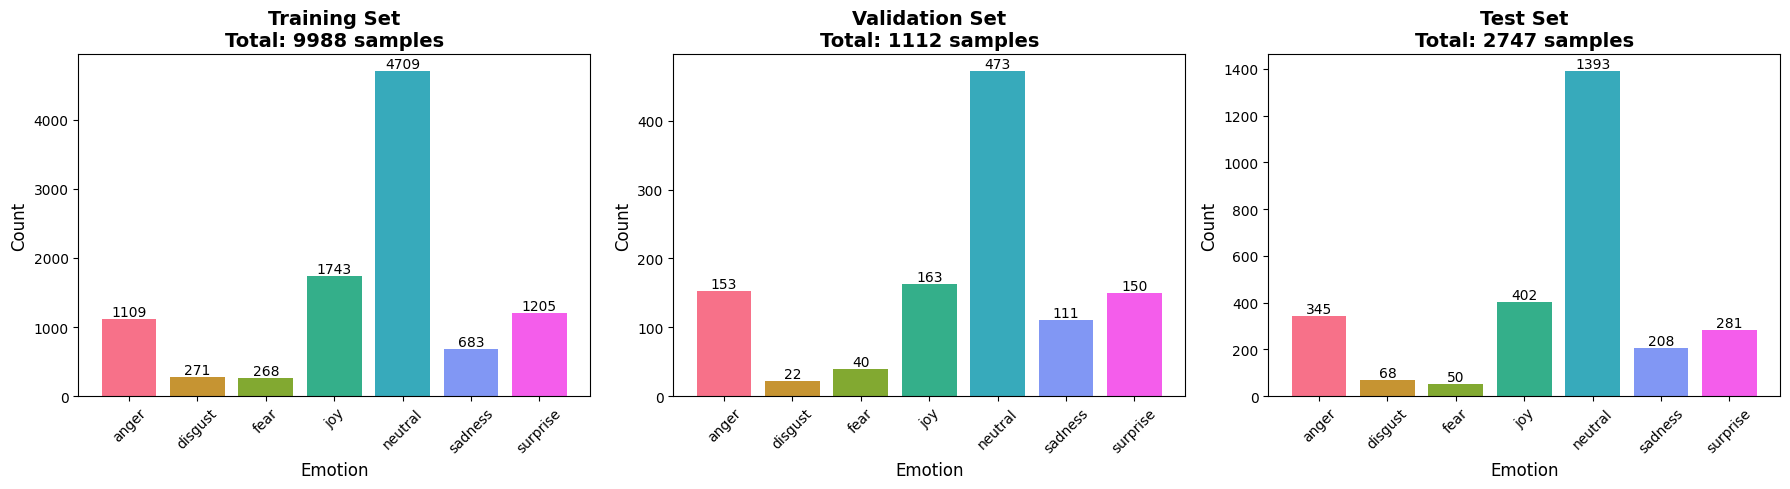


Plotting feature distributions...
✓ Feature distribution plot saved


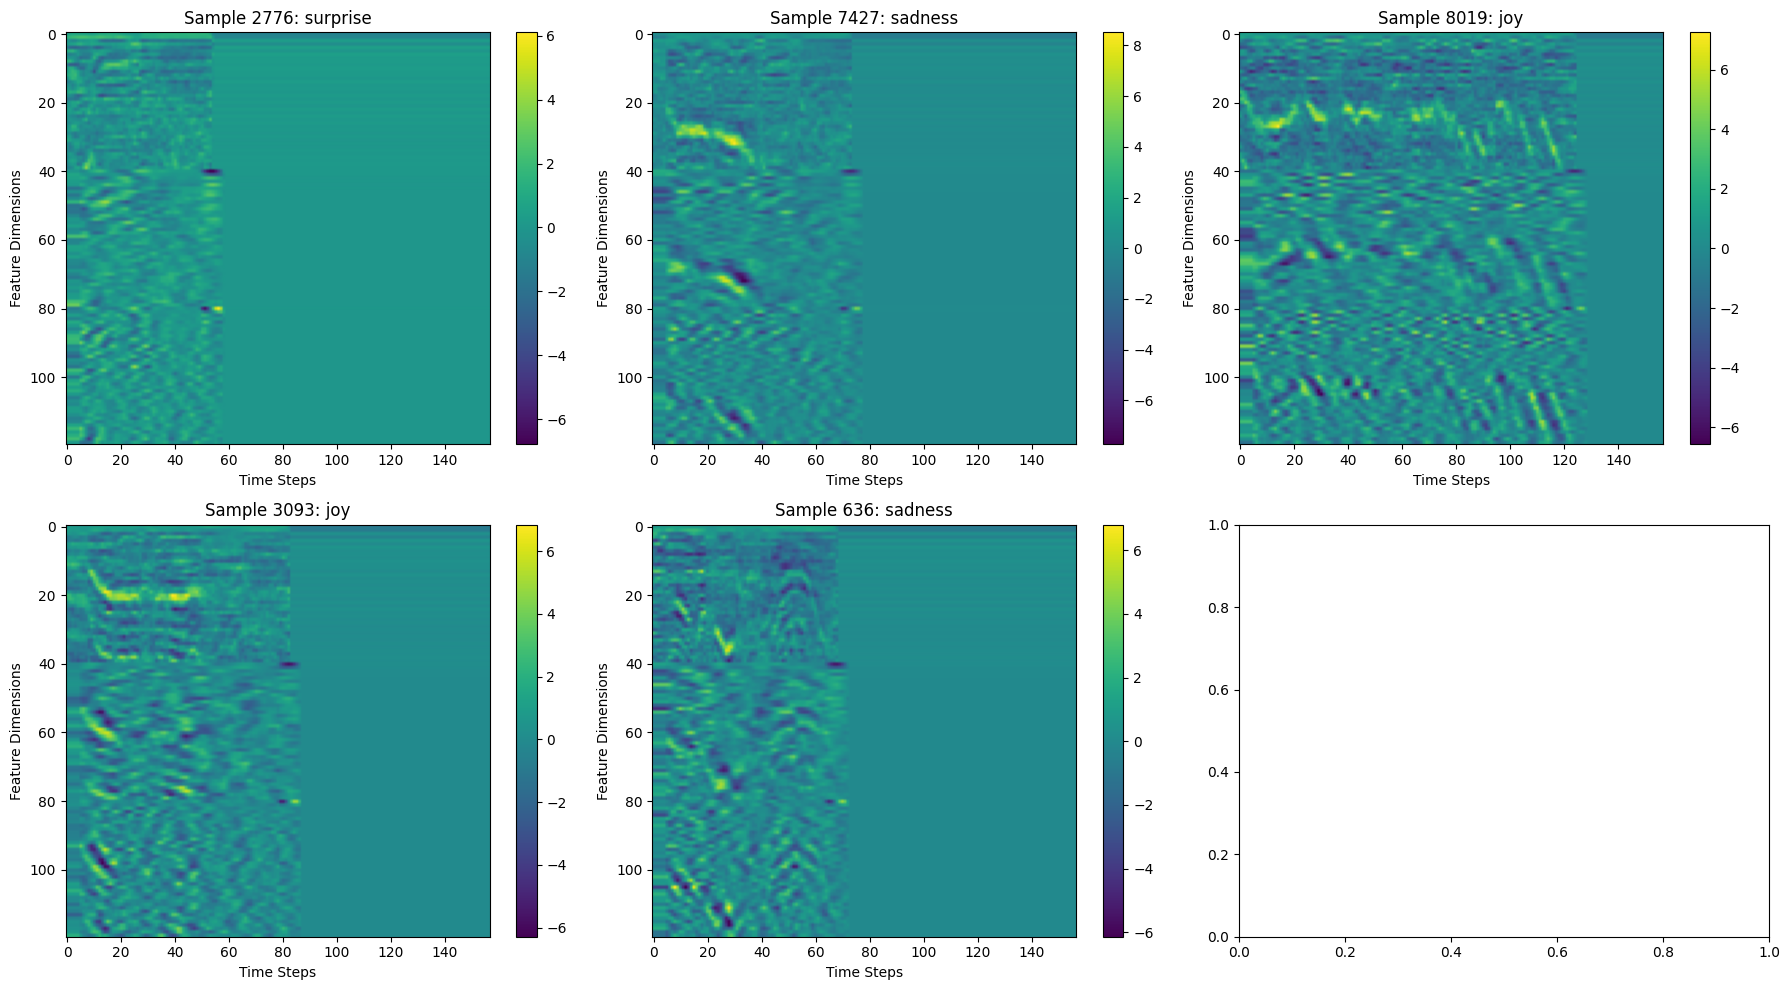

✓ Data report saved to: /content/drive/MyDrive/MELD/preprocessed_data/data_report.txt

VERIFICATION COMPLETE!

All verification outputs saved to: /content/drive/MyDrive/MELD/preprocessed_data

Generated files:
  - label_distribution.png
  - feature_samples.png
  - data_report.txt

✓ Data is ready for model training!


In [24]:
if __name__ == "__main__":
    print("\n" + "="*70)
    print("MELD AUDIO DATA VERIFICATION")
    print("="*70 + "\n")

    verifier = DataVerifier()
    verifier.verify_all()

In [19]:
!pip install tensorflow scikit-learn seaborn -q

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Bidirectional, Conv1D, MaxPooling1D,
    Dropout, BatchNormalization, Flatten, Concatenate,
    GlobalAveragePooling1D, Attention, LayerNormalization
)
import pickle
import os
from datetime import datetime

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [7]:
class Config:
    """Model configuration"""
    # Data paths
    DATA_DIR = '/content/preprocessed_data'
    MODEL_DIR = '/content/models'
    RESULTS_DIR = '/content/results'

    # Model architecture
    INPUT_SHAPE = (120, 157) # (features, time_steps)
    NUM_CLASSES = 7

    # CNN parameters
    CNN_FILTERS = [64, 128, 256]
    CNN_KERNEL_SIZE = 3
    CNN_POOL_SIZE = 2

    # LSTM parameters
    LSTM_UNITS = [128, 64]
    BIDIRECTIONAL = True

    # Training parameters
    BATCH_SIZE = 32
    EPOCHS = 30
    LEARNING_RATE = 0.01
    EARLY_STOPPING_PATIENCE = 5
    REDUCE_LR_PATIENCE = 3

    # 🆕 NEW: Regularization with multiple options
    DROPOUT_RATE = 0.5              # Main dropout rate
    CNN_DROPOUT = 0.3               # Dropout after CNN layers
    LSTM_DROPOUT = 0.4              # Dropout in LSTM layers
    LSTM_RECURRENT_DROPOUT = 0.2    # Recurrent dropout in LSTM
    FC_DROPOUT = 0.5                # Dropout in fully connected layers

    L2_REG = 0.001

    # 🆕 NEW: Normalization options
    USE_BATCH_NORM = True           # Use Batch Normalization
    USE_LAYER_NORM = False          # Use Layer Normalization (alternative to BatchNorm)
    NORM_MOMENTUM = 0.99            # BatchNorm momentum

    # 🆕 NEW: Experiment name (for tracking different configurations)
    EXPERIMENT_NAME = "baseline"    # Change this for different experiments

    # Class imbalance handling
    USE_CLASS_WEIGHTS = True

    # Emotion labels
    EMOTION_LABELS = {
        0: 'anger',
        1: 'disgust',
        2: 'fear',
        3: 'joy',
        4: 'neutral',
        5: 'sadness',
        6: 'surprise'
    }

config = Config()

In [8]:
def load_data():
    """Load preprocessed data"""
    print("="*80)
    print(" "*25 + "LOADING DATA")
    print("="*80)

    # 🆕 CHANGED: Load from Google Drive
    GDRIVE_DATA_PATH = '/content/drive/MyDrive/MELD/preprocessed_data'

    print(f"\n📂 Loading from: {GDRIVE_DATA_PATH}")

    X_train = np.load(os.path.join(GDRIVE_DATA_PATH, 'X_train.npy'))
    X_dev = np.load(os.path.join(GDRIVE_DATA_PATH, 'X_dev.npy'))
    X_test = np.load(os.path.join(GDRIVE_DATA_PATH, 'X_test.npy'))

    y_train = np.load(os.path.join(GDRIVE_DATA_PATH, 'y_train.npy'))
    y_dev = np.load(os.path.join(GDRIVE_DATA_PATH, 'y_dev.npy'))
    y_test = np.load(os.path.join(GDRIVE_DATA_PATH, 'y_test.npy'))

    print(f"\n✓ Data loaded successfully!")
    print(f"  Train: X={X_train.shape}, y={y_train.shape}")
    print(f"  Dev:   X={X_dev.shape}, y={y_dev.shape}")
    print(f"  Test:  X={X_test.shape}, y={y_test.shape}")

    # Reshape for model (add channel dimension if needed)
    # Current shape: (samples, features, time_steps)
    # We'll transpose to: (samples, time_steps, features) for LSTM
    X_train = np.transpose(X_train, (0, 2, 1))
    X_dev = np.transpose(X_dev, (0, 2, 1))
    X_test = np.transpose(X_test, (0, 2, 1))

    print(f"\n✓ Reshaped for model:")
    print(f"  Train: {X_train.shape}")
    print(f"  Dev:   {X_dev.shape}")
    print(f"  Test:  {X_test.shape}")

    return X_train, X_dev, X_test, y_train, y_dev, y_test

In [9]:
def compute_class_weights(y_train):
    """Compute class weights for imbalanced dataset"""
    print("\n" + "="*80)
    print(" "*25 + "CLASS WEIGHTS")
    print("="*80)

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

    print("\nComputed class weights:")
    for class_idx, weight in class_weight_dict.items():
        emotion = config.EMOTION_LABELS[class_idx]
        print(f"  {emotion:12s} (class {class_idx}): {weight:.4f}")

    return class_weight_dict

In [10]:
def build_bilstm_cnn_model(input_shape, num_classes):
    """
    Build hybrid BiLSTM + CNN model with enhanced normalization and dropout
    """
    print("\n" + "="*80)
    print(" "*25 + "BUILDING MODEL")
    print("="*80)

    # Print configuration
    print(f"\nModel Configuration:")
    print(f"  Experiment: {config.EXPERIMENT_NAME}")
    print(f"  CNN Dropout: {config.CNN_DROPOUT}")
    print(f"  LSTM Dropout: {config.LSTM_DROPOUT}")
    print(f"  LSTM Recurrent Dropout: {config.LSTM_RECURRENT_DROPOUT}")
    print(f"  FC Dropout: {config.FC_DROPOUT}")
    print(f"  Batch Normalization: {config.USE_BATCH_NORM}")
    print(f"  Layer Normalization: {config.USE_LAYER_NORM}")

    # Input layer
    inputs = Input(shape=input_shape, name='input')

    # 🆕 CHANGED: CNN BRANCH with configurable dropout and normalization
    x_cnn = inputs
    for i, filters in enumerate(config.CNN_FILTERS):
        x_cnn = Conv1D(
            filters=filters,
            kernel_size=config.CNN_KERNEL_SIZE,
            padding='same',
            activation='relu',
            name=f'conv1d_{i+1}'
        )(x_cnn)

        # 🆕 NEW: Configurable normalization
        if config.USE_BATCH_NORM:
            x_cnn = BatchNormalization(
                momentum=config.NORM_MOMENTUM,
                name=f'bn_cnn_{i+1}'
            )(x_cnn)
        elif config.USE_LAYER_NORM:
            x_cnn = LayerNormalization(name=f'ln_cnn_{i+1}')(x_cnn)

        x_cnn = MaxPooling1D(
            pool_size=config.CNN_POOL_SIZE,
            name=f'maxpool_{i+1}'
        )(x_cnn)

        # 🆕 CHANGED: Use CNN-specific dropout
        x_cnn = Dropout(config.CNN_DROPOUT, name=f'dropout_cnn_{i+1}')(x_cnn)

    # Global pooling for CNN features
    cnn_features = GlobalAveragePooling1D(name='cnn_global_pool')(x_cnn)

    # 🆕 CHANGED: BiLSTM BRANCH with configurable dropout and normalization
    x_lstm = inputs
    for i, units in enumerate(config.LSTM_UNITS):
        return_sequences = (i < len(config.LSTM_UNITS) - 1)

        # 🆕 CHANGED: Use LSTM-specific dropout rates
        x_lstm = Bidirectional(
            LSTM(
                units=units,
                return_sequences=return_sequences,
                dropout=config.LSTM_DROPOUT,
                recurrent_dropout=config.LSTM_RECURRENT_DROPOUT,
                name=f'lstm_{i+1}'
            ),
            name=f'bidirectional_{i+1}'
        )(x_lstm)

        # 🆕 NEW: Configurable normalization
        if config.USE_BATCH_NORM:
            x_lstm = BatchNormalization(
                momentum=config.NORM_MOMENTUM,
                name=f'bn_lstm_{i+1}'
            )(x_lstm)
        elif config.USE_LAYER_NORM:
            x_lstm = LayerNormalization(name=f'ln_lstm_{i+1}')(x_lstm)

    # x_lstm is now (batch, features) after last LSTM without return_sequences
    lstm_features = x_lstm

    # FEATURE FUSION
    merged = Concatenate(name='feature_fusion')([cnn_features, lstm_features])

    # 🆕 CHANGED: CLASSIFICATION HEAD with configurable dropout and normalization
    x = Dense(256, activation='relu', name='fc1')(merged)

    # 🆕 NEW: Configurable normalization
    if config.USE_BATCH_NORM:
        x = BatchNormalization(momentum=config.NORM_MOMENTUM, name='bn_fc1')(x)
    elif config.USE_LAYER_NORM:
        x = LayerNormalization(name='ln_fc1')(x)

    # 🆕 CHANGED: Use FC-specific dropout
    x = Dropout(config.FC_DROPOUT, name='dropout_fc1')(x)

    x = Dense(128, activation='relu', name='fc2')(x)

    if config.USE_BATCH_NORM:
        x = BatchNormalization(momentum=config.NORM_MOMENTUM, name='bn_fc2')(x)
    elif config.USE_LAYER_NORM:
        x = LayerNormalization(name='ln_fc2')(x)

    x = Dropout(config.FC_DROPOUT, name='dropout_fc2')(x)

    # Output layer
    outputs = Dense(num_classes, activation='softmax', name='output')(x)

    # Create model
    model = models.Model(inputs=inputs, outputs=outputs, name='BiLSTM_CNN')

    print("\n✓ Model architecture built successfully!")

    return model

In [11]:
def plot_model_architecture(model):
    """Plot model architecture"""
    try:
        tf.keras.utils.plot_model(
            model,
            to_file=os.path.join(config.RESULTS_DIR, 'model_architecture.png'),
            show_shapes=True,
            show_layer_names=True,
            rankdir='TB',
            expand_nested=True,
            dpi=300
        )
        print("✓ Model architecture plot saved")
    except Exception as e:
        print(f"⚠ Could not plot model: {e}")

In [12]:
def train_model(model, X_train, y_train, X_val, y_val, class_weights=None):
    """Train the model with callbacks"""
    print("\n" + "="*80)
    print(" "*25 + "TRAINING MODEL")
    print("="*80)

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=config.LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_path = os.path.join(
        config.MODEL_DIR,
        f'best_model_{config.EXPERIMENT_NAME}_{timestamp}.keras'
    )

    callback_list = [
        # Save best model
        callbacks.ModelCheckpoint(
            filepath=model_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),

        # Early stopping
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=config.EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        # Reduce learning rate on plateau
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=config.REDUCE_LR_PATIENCE,
            min_lr=1e-6,
            verbose=1
        ),

        # TensorBoard
        callbacks.TensorBoard(
            log_dir=os.path.join(
                config.RESULTS_DIR,
                'logs',
                f'{config.EXPERIMENT_NAME}_{timestamp}'
            ),
            histogram_freq=1
        )
    ]

    # Train model
    print(f"\nStarting training...")
    print(f"  Batch size: {config.BATCH_SIZE}")
    print(f"  Epochs: {config.EPOCHS}")
    print(f"  Learning rate: {config.LEARNING_RATE}")

    history = model.fit(
        X_train, y_train,
        batch_size=config.BATCH_SIZE,
        epochs=config.EPOCHS,
        validation_data=(X_val, y_val),
        class_weight=class_weights if config.USE_CLASS_WEIGHTS else None,
        callbacks=callback_list,
        verbose=1
    )

    print(f"\n✓ Training completed!")
    print(f"✓ Best model saved to: {model_path}")

    return history, model_path

In [13]:
def plot_training_history(history):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14, weight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3)

    # Loss
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14, weight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'training_history.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Training history plot saved")

In [14]:
def evaluate_model(model, X_test, y_test):
    """Evaluate model on test set"""
    print("\n" + "="*80)
    print(" "*25 + "MODEL EVALUATION")
    print("="*80)

    # Predictions
    y_pred_probs = model.predict(X_test, batch_size=config.BATCH_SIZE)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Overall accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n✓ Test Accuracy: {accuracy*100:.2f}%")

    # Classification report
    print("\n" + "="*80)
    print("CLASSIFICATION REPORT")
    print("="*80)

    report = classification_report(
        y_test, y_pred,
        target_names=[config.EMOTION_LABELS[i] for i in range(config.NUM_CLASSES)],
        digits=4
    )
    print(report)

    # Save report
    with open(os.path.join(config.RESULTS_DIR, 'classification_report.txt'), 'w') as f:
        f.write(f"Test Accuracy: {accuracy*100:.2f}%\n\n")
        f.write(report)

    return y_pred, y_pred_probs

In [15]:
def plot_confusion_matrix(y_true, y_pred):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=[config.EMOTION_LABELS[i] for i in range(config.NUM_CLASSES)],
        yticklabels=[config.EMOTION_LABELS[i] for i in range(config.NUM_CLASSES)],
        cbar_kws={'label': 'Count'}
    )
    plt.title('Confusion Matrix', fontsize=16, weight='bold', pad=20)
    plt.xlabel('Predicted Emotion', fontsize=12, weight='bold')
    plt.ylabel('True Emotion', fontsize=12, weight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'confusion_matrix.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Confusion matrix saved")

In [16]:
def plot_per_class_metrics(y_true, y_pred):
    """Plot per-class precision, recall, F1-score"""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None
    )

    emotions = [config.EMOTION_LABELS[i] for i in range(config.NUM_CLASSES)]

    x = np.arange(len(emotions))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 7))

    ax.bar(x - width, precision, width, label='Precision', color='#3498db')
    ax.bar(x, recall, width, label='Recall', color='#e74c3c')
    ax.bar(x + width, f1, width, label='F1-Score', color='#2ecc71')

    ax.set_xlabel('Emotion', fontsize=12, weight='bold')
    ax.set_ylabel('Score', fontsize=12, weight='bold')
    ax.set_title('Per-Class Metrics', fontsize=16, weight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(emotions, rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.0])

    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'per_class_metrics.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Per-class metrics plot saved")

In [23]:
def build_simple_baseline_model(input_shape, num_classes):
    """Simple baseline model with STRONG regularization to prevent overfitting"""
    inputs = Input(shape=input_shape, name='input')

    # 🆕 CHANGED: Add dropout to LSTM itself
    x = Bidirectional(
        LSTM(64,
             dropout=0.5,              # 🆕 NEW: Dropout on inputs
             recurrent_dropout=0.3,    # 🆕 NEW: Dropout on recurrent connections
             return_sequences=False)
    )(inputs)
    x = Dropout(0.5)(x)  # 🆕 CHANGED: Increased from 0.3 to 0.5

    # 🆕 CHANGED: Add BatchNormalization
    x = BatchNormalization()(x)

    # Simple classification with stronger dropout
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)  # 🆕 CHANGED: Increased from 0.3 to 0.5
    x = BatchNormalization()(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)  # 🆕 NEW: Added dropout here too

    outputs = Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='Simple_Baseline_Regularized')
    return model

In [26]:
def quick_diagnostic_run():
    """
    Run a quick diagnostic to see if model can learn at all
    Very fast - just 10 epochs to check if setup is correct
    """
    print("\n" + "="*80)
    print(" "*20 + "QUICK DIAGNOSTIC RUN (10 EPOCHS)")
    print("="*80)
    print("\nThis will help identify if the model CAN learn before full training")
    print("Expected behavior:")
    print("  ✓ Training accuracy should increase")
    print("  ✓ Training loss should decrease")
    print("  ? Validation accuracy may plateau (this is what we're investigating)")
    print()

    # Load data
    X_train, X_dev, X_test, y_train, y_dev, y_test = load_data()

    # Use small subset for speed
    subset_size = 2000
    X_train_small = X_train[:subset_size]
    y_train_small = y_train[:subset_size]

    print(f"\n🔬 Using subset: {subset_size} training samples")

    class_weights = compute_class_weights(y_train_small)

    print("\n⚠️  Running WITHOUT class weights (testing dropout only)")
    class_weights = None

    print("\n✅ Using class weights to handle imbalance")

    # Build model
    model = build_simple_baseline_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=config.NUM_CLASSES
    )

    # Compile
    model.compile(
        optimizer=Adam(learning_rate=config.LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Quick training - just 10 epochs
    print("\n🚀 Running quick diagnostic (10 epochs)...")
    history = model.fit(
        X_train_small, y_train_small,
        batch_size=config.BATCH_SIZE,
        epochs=10,
        validation_data=(X_dev, y_dev),
        class_weight=class_weights,
        verbose=1
    )

    # Analyze results
    print("\n" + "="*80)
    print("DIAGNOSTIC RESULTS")
    print("="*80)

    train_acc_start = history.history['accuracy'][0]
    train_acc_end = history.history['accuracy'][-1]
    val_acc_start = history.history['val_accuracy'][0]
    val_acc_end = history.history['val_accuracy'][-1]

    train_loss_start = history.history['loss'][0]
    train_loss_end = history.history['loss'][-1]
    val_loss_start = history.history['val_loss'][0]
    val_loss_end = history.history['val_loss'][-1]

    print(f"\nTraining Accuracy:   {train_acc_start:.4f} → {train_acc_end:.4f} ", end="")
    if train_acc_end > train_acc_start + 0.05:
        print("✅ IMPROVING")
    else:
        print("❌ NOT IMPROVING - Model can't learn!")

    print(f"Validation Accuracy: {val_acc_start:.4f} → {val_acc_end:.4f} ", end="")
    if val_acc_end > val_acc_start + 0.02:
        print("✅ IMPROVING")
    elif abs(val_acc_end - val_acc_start) < 0.02:
        print("⚠️  PLATEAUED - This is the problem!")
    else:
        print("❌ DECREASING")

    print(f"\nTraining Loss:       {train_loss_start:.4f} → {train_loss_end:.4f} ", end="")
    if train_loss_end < train_loss_start - 0.1:
        print("✅ DECREASING")
    else:
        print("❌ NOT DECREASING")

    print(f"Validation Loss:     {val_loss_start:.4f} → {val_loss_end:.4f} ", end="")
    if val_loss_end < val_loss_start - 0.05:
        print("✅ DECREASING")
    elif abs(val_loss_end - val_loss_start) < 0.05:
        print("⚠️  PLATEAUED")
    else:
        print("❌ INCREASING - Overfitting!")

    # Diagnosis
    print("\n" + "="*80)
    print("DIAGNOSIS")
    print("="*80)

    if train_acc_end < 0.3:
        print("\n❌ CRITICAL: Model barely learning on training data")
        print("   Possible causes:")
        print("   - Learning rate too high or too low")
        print("   - Model architecture issue")
        print("   - Data normalization problem")
        print("   - Loss function mismatch")

    elif train_acc_end > 0.7 and val_acc_end < 0.4:
        print("\n⚠️  SEVERE OVERFITTING")
        print("   Training accuracy high but validation low")
        print("   Possible causes:")
        print("   - Need more dropout")
        print("   - Need more regularization")
        print("   - Training set too small or not representative")
        print("   - Model too complex for the data")

    elif val_acc_end < 0.35:
        print("\n⚠️  LOW VALIDATION ACCURACY")
        print("   Model not generalizing well")
        print("   Possible causes:")
        print("   - Features not discriminative enough")
        print("   - Class imbalance too severe")
        print("   - Validation set very different from training")
        print("   - Task is inherently difficult (audio-only emotion recognition)")

    else:
        print("\n✅ Model is learning, but may need tuning")
        print("   Proceed with full training and experiments")

    # Plot quick results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'], label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val', linewidth=2)
    ax1.set_title('Quick Diagnostic - Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'], label='Train', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val', linewidth=2)
    ax2.set_title('Quick Diagnostic - Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'quick_diagnostic.png'), dpi=300)
    plt.show()

    print(f"\n✅ Diagnostic plot saved")

    return history


                    QUICK DIAGNOSTIC RUN (10 EPOCHS)

This will help identify if the model CAN learn before full training
Expected behavior:
  ✓ Training accuracy should increase
  ✓ Training loss should decrease
  ? Validation accuracy may plateau (this is what we're investigating)

                         LOADING DATA

📂 Loading from: /content/drive/MyDrive/MELD/preprocessed_data

✓ Data loaded successfully!
  Train: X=(9988, 120, 157), y=(9988,)
  Dev:   X=(1112, 120, 157), y=(1112,)
  Test:  X=(2747, 120, 157), y=(2747,)

✓ Reshaped for model:
  Train: (9988, 157, 120)
  Dev:   (1112, 157, 120)
  Test:  (2747, 157, 120)

🔬 Using subset: 2000 training samples

                         CLASS WEIGHTS

Computed class weights:
  anger        (class 0): 1.2698
  disgust      (class 1): 5.1948
  fear         (class 2): 5.9524
  joy          (class 3): 0.8258
  neutral      (class 4): 0.3020
  sadness      (class 5): 1.8797
  surprise     (class 6): 1.2531

⚠️  Running WITHOUT class weig

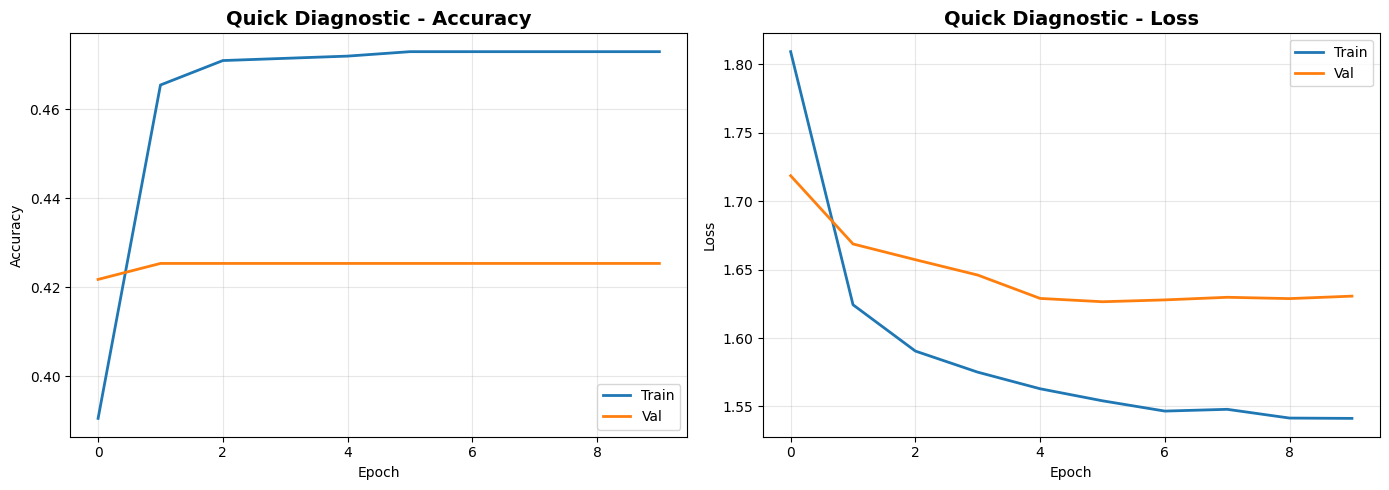


✅ Diagnostic plot saved


In [27]:
def main():
    """Main training pipeline"""
    # Create directories
    os.makedirs(config.MODEL_DIR, exist_ok=True)
    os.makedirs(config.RESULTS_DIR, exist_ok=True)

    print("\n" + "="*80)
    print(" "*15 + "BiLSTM+CNN SPEECH EMOTION RECOGNITION")
    print(" "*25 + "MELD Dataset - 7 Emotions")
    print("="*80)

    # Load data
    X_train, X_dev, X_test, y_train, y_dev, y_test = load_data()

    # Compute class weights
    class_weights = compute_class_weights(y_train) if config.USE_CLASS_WEIGHTS else None

    # Build model
    model = build_bilstm_cnn_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        num_classes=config.NUM_CLASSES
    )

    # Print model summary
    print("\n" + "="*80)
    print("MODEL SUMMARY")
    print("="*80)
    model.summary()

    # Plot model architecture
    plot_model_architecture(model)

    # Train model
    history, model_path = train_model(
        model, X_train, y_train, X_dev, y_dev, class_weights
    )

    # Plot training history
    plot_training_history(history)

    # Load best model
    print(f"\nLoading best model from: {model_path}")
    best_model = keras.models.load_model(model_path)

    # Evaluate on test set
    y_pred, y_pred_probs = evaluate_model(best_model, X_test, y_test)

    # Plot results
    plot_confusion_matrix(y_test, y_pred)
    plot_per_class_metrics(y_test, y_pred)

    print("\n" + "="*80)
    print(" "*25 + "TRAINING COMPLETE!")
    print("="*80)
    print(f"\nAll results saved to: {config.RESULTS_DIR}")
    print(f"Best model saved to: {model_path}")

    return best_model, history


if __name__ == "__main__":

    # Create necessary directories
    import os
    os.makedirs('/content/models', exist_ok=True)
    os.makedirs('/content/results', exist_ok=True)

    # Choose mode
    MODE = "diagnostic"

    if MODE == "diagnostic":
        # 🆕 NEW: Quick 10-epoch test to see if model can learn
        quick_diagnostic_run()

    elif MODE == "single":
        # Run single experiment with current config
        main()

    elif MODE == "experiments":
        # Run multiple experiments to compare dropout configurations
        results_df = run_experiments()

        print("\n" + "="*80)
        print("ALL EXPERIMENTS COMPLETE!")
        print("="*80)
        print(f"\nResults saved to: {config.RESULTS_DIR}/dropout_experiments_results.csv")
        print(f"Comparison plot: {config.RESULTS_DIR}/experiment_comparison.png")

In [41]:
def run_experiments():
    """
    Run multiple experiments with different dropout configurations
    to show tuning and optimization process
    """
    print("\n" + "="*80)
    print(" "*20 + "RUNNING DROPOUT TUNING EXPERIMENTS")
    print("="*80)

    # Define different dropout configurations to test
    experiments = [
        {
            'name': 'baseline',
            'cnn_dropout': 0.3,
            'lstm_dropout': 0.4,
            'lstm_recurrent_dropout': 0.2,
            'fc_dropout': 0.5,
            'use_batch_norm': True,
            'use_layer_norm': False
        },
        {
            'name': 'low_dropout',
            'cnn_dropout': 0.2,
            'lstm_dropout': 0.2,
            'lstm_recurrent_dropout': 0.1,
            'fc_dropout': 0.3,
            'use_batch_norm': True,
            'use_layer_norm': False
        },
        {
            'name': 'high_dropout',
            'cnn_dropout': 0.5,
            'lstm_dropout': 0.5,
            'lstm_recurrent_dropout': 0.3,
            'fc_dropout': 0.6,
            'use_batch_norm': True,
            'use_layer_norm': False
        },
        {
            'name': 'progressive_dropout',
            'cnn_dropout': 0.2,
            'lstm_dropout': 0.3,
            'lstm_recurrent_dropout': 0.2,
            'fc_dropout': 0.5,
            'use_batch_norm': True,
            'use_layer_norm': False
        },
        {
            'name': 'layer_norm',
            'cnn_dropout': 0.3,
            'lstm_dropout': 0.4,
            'lstm_recurrent_dropout': 0.2,
            'fc_dropout': 0.5,
            'use_batch_norm': False,
            'use_layer_norm': True
        }
    ]

    # Store results
    results_summary = []

    # Load data once
    X_train, X_dev, X_test, y_train, y_dev, y_test = load_data()
    class_weights = compute_class_weights(y_train)

    # Run each experiment
    for exp in experiments:
        print("\n" + "="*80)
        print(f"EXPERIMENT: {exp['name'].upper()}")
        print("="*80)
        print(f"CNN Dropout: {exp['cnn_dropout']}")
        print(f"LSTM Dropout: {exp['lstm_dropout']}")
        print(f"LSTM Recurrent Dropout: {exp['lstm_recurrent_dropout']}")
        print(f"FC Dropout: {exp['fc_dropout']}")
        print(f"Batch Norm: {exp['use_batch_norm']}")
        print(f"Layer Norm: {exp['use_layer_norm']}")

        # Update config
        config.EXPERIMENT_NAME = exp['name']
        config.CNN_DROPOUT = exp['cnn_dropout']
        config.LSTM_DROPOUT = exp['lstm_dropout']
        config.LSTM_RECURRENT_DROPOUT = exp['lstm_recurrent_dropout']
        config.FC_DROPOUT = exp['fc_dropout']
        config.USE_BATCH_NORM = exp['use_batch_norm']
        config.USE_LAYER_NORM = exp['use_layer_norm']

        # Build model
        model = build_bilstm_cnn_model(
            input_shape=(X_train.shape[1], X_train.shape[2]),
            num_classes=config.NUM_CLASSES
        )

        # Train model
        history, model_path = train_model(
            model, X_train, y_train, X_dev, y_dev, class_weights
        )

        # Evaluate
        y_pred, y_pred_probs = evaluate_model(model, X_test, y_test)

        # Store results
        best_val_acc = max(history.history['val_accuracy'])
        final_train_acc = history.history['accuracy'][-1]
        test_acc = accuracy_score(y_test, y_pred)

        results_summary.append({
            'experiment': exp['name'],
            'cnn_dropout': exp['cnn_dropout'],
            'lstm_dropout': exp['lstm_dropout'],
            'fc_dropout': exp['fc_dropout'],
            'normalization': 'BatchNorm' if exp['use_batch_norm'] else 'LayerNorm',
            'best_val_acc': best_val_acc,
            'final_train_acc': final_train_acc,
            'test_acc': test_acc,
            'overfitting': final_train_acc - best_val_acc
        })

        print(f"\n✅ {exp['name']} complete!")
        print(f"   Best Val Acc: {best_val_acc:.4f}")
        print(f"   Test Acc: {test_acc:.4f}")

    # Create comparison report
    print("\n" + "="*80)
    print("EXPERIMENT COMPARISON")
    print("="*80)

    results_df = pd.DataFrame(results_summary)
    print("\n" + results_df.to_string(index=False))

    # Save results
    results_df.to_csv(
        os.path.join(config.RESULTS_DIR, 'dropout_experiments_results.csv'),
        index=False
    )

    # Plot comparison
    plot_experiment_comparison(results_df)

    return results_df


def plot_experiment_comparison(results_df):
    """Plot comparison of different experiments"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Accuracy comparison
    ax = axes[0, 0]
    x = np.arange(len(results_df))
    width = 0.25

    ax.bar(x - width, results_df['final_train_acc'], width, label='Train', alpha=0.8)
    ax.bar(x, results_df['best_val_acc'], width, label='Val', alpha=0.8)
    ax.bar(x + width, results_df['test_acc'], width, label='Test', alpha=0.8)

    ax.set_xlabel('Experiment', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Accuracy Comparison Across Experiments', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['experiment'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # 2. Overfitting analysis
    ax = axes[0, 1]
    colors = ['green' if x < 0.05 else 'orange' if x < 0.1 else 'red'
              for x in results_df['overfitting']]
    bars = ax.barh(results_df['experiment'], results_df['overfitting'], color=colors, alpha=0.7)
    ax.set_xlabel('Overfitting (Train - Val)', fontsize=12, fontweight='bold')
    ax.set_title('Overfitting Analysis\n(Lower is Better)', fontsize=14, fontweight='bold')
    ax.axvline(x=0.05, color='green', linestyle='--', alpha=0.5, label='Good (<0.05)')
    ax.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='Moderate (<0.1)')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)

    # 3. Dropout rates comparison
    ax = axes[1, 0]
    experiments = results_df['experiment']

    ax.plot(experiments, results_df['cnn_dropout'], marker='o', label='CNN', linewidth=2)
    ax.plot(experiments, results_df['lstm_dropout'], marker='s', label='LSTM', linewidth=2)
    ax.plot(experiments, results_df['fc_dropout'], marker='^', label='FC', linewidth=2)

    ax.set_xlabel('Experiment', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dropout Rate', fontsize=12, fontweight='bold')
    ax.set_title('Dropout Rates per Experiment', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 4. Test accuracy vs dropout
    ax = axes[1, 1]
    avg_dropout = (results_df['cnn_dropout'] + results_df['lstm_dropout'] +
                   results_df['fc_dropout']) / 3

    scatter = ax.scatter(avg_dropout, results_df['test_acc'],
                        s=200, alpha=0.6, c=results_df['test_acc'],
                        cmap='RdYlGn', edgecolors='black', linewidth=2)

    for i, exp in enumerate(results_df['experiment']):
        ax.annotate(exp, (avg_dropout.iloc[i], results_df['test_acc'].iloc[i]),
                   fontsize=9, ha='center', va='bottom')

    ax.set_xlabel('Average Dropout Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Test Accuracy vs Average Dropout', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Test Accuracy')

    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'experiment_comparison.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✅ Comparison plot saved to {config.RESULTS_DIR}/experiment_comparison.png")